### Business Problem:

A global e-commerce company operating across multiple regions manages end-to-end order fulfillment, including shipping and delivery, for products like sporting goods. The company is facing inconsistent delivery performance, where actual shipping times often deviate from scheduled timelines, leading to late deliveries and unpredictable order profitability.

#### Goal:

Analyze delivery operations, identify bottlenecks and build a predictive system to reduce delays, optimize shipping decisions, and improve overall profitability and efficiency.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings

filterwarnings('ignore')

In [2]:
# Set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [3]:
df = pd.read_csv('DataCoSupplyChainDataset.csv', encoding = 'latin-1')

In [4]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [5]:
df.shape

(180519, 53)

In [6]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

- so we have a master data, aggregated from multiple tables like delivery time, product details, customer details, order details

### EDA

In [7]:
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

- ### Data Cleaning

In [8]:
# Dropping coloumns because we don't need these for delivery time analysis.
columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',   # identical to Order Profit Per Order
    'Product Status',       # have only one value
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

# dropping columns that are either fully missing, redundant, or have only one value (and thus no variance)
df = df.drop(columns=columns_to_drop)

# removing canceled orders since they are not relevant for delivery time analysis and may have different patterns than completed orders
df = df[df['Delivery Status'] != 'Shipping canceled']

# Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

# after data cleaning, let's check the overview again to see how the dataset has changed
print('rows, cols:', df.shape)

print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 20)

Missing values (top 5):
Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Sales per customer               0
Delivery Status                  0
dtype: int64


In [9]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [10]:
for col in df.columns:
    if df[col].nunique()<10:
        print(f'\n{col} value counts: ')
        print(df[col].value_counts())


Type value counts: 
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts: 
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts: 
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts: 
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts: 
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts: 
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts: 
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts: 
Order Status
CO

In [11]:
df['Customer Country'].reset_index()

,index,Customer Country
0,0,Puerto Rico
1,1,Puerto Rico
2,2,EE. UU.
3,3,EE. UU.
4,4,Puerto Rico
...,...,...
172760,180514,EE. UU.
172761,180515,EE. UU.
172762,180516,EE. UU.
172763,180517,Puerto Rico


 - ### Feature engineering

In [14]:
# calculating order processing time and delay
df['Order Processing Time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.days

df['Delay'] = (
    df['Order Processing Time'] - df['Days for shipment (scheduled)']
)

df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour

In [15]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,...,Product Name,Product Price,shipping date (DateOrders),Shipping Mode,Order Processing Time,Delay,Is_Delayed,order_month,order_day,order_hour
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,...,Smart watch,327.75,2018-02-03 22:56:00,Standard Class,3,-1,False,1,Wednesday,22
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,...,Smart watch,327.75,2018-01-18 12:27:00,Standard Class,5,1,True,1,Saturday,12
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,...,Smart watch,327.75,2018-01-17 12:06:00,Standard Class,4,0,False,1,Saturday,12
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,...,Smart watch,327.75,2018-01-16 11:45:00,Standard Class,3,-1,False,1,Saturday,11
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,...,Smart watch,327.75,2018-01-15 11:24:00,Standard Class,2,-2,False,1,Saturday,11


In [16]:
df['Is_Delayed'].value_counts()

Is_Delayed
True     94523
False    78242
Name: count, dtype: int64

In [17]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-12 15:25:39.457991936,0.120801,203.828493,22.032360,141.278595,2016-06-16 03:25:14.452927488,3.472816,0.539716,6.235511,11.482604
min,0.000000,0.000000,7.490000,0.000000,2015-01-01 00:00:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-21 18:01:00,0.080000,119.980003,7.030000,50.000000,2015-09-25 08:59:00,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-11 08:11:00,0.270000,199.919998,31.520000,59.990002,2016-06-15 03:38:00,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 21:08:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 08:00:00,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.670187,1.494150,3.405593,6.927276


In [18]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [19]:
df['Order Profit Per Order'].reset_index()

,index,Order Profit Per Order
0,0,91.250000
1,1,-249.089996
2,2,-247.779999
3,3,22.860001
4,4,134.210007
...,...,...
172760,180514,40.000000
172761,180515,-613.770019
172762,180516,141.110001
172763,180517,186.229996


In [20]:
df['Order Profit Per Order']>0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 172765, dtype: bool

In [21]:
df['Profitability Flag'] = np.where(df['Order Profit Per Order']>0, 'Profit', np.where(df['Order Profit Per Order']<0, 'Loss', 'Break-even'))

In [22]:
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

In [23]:
df['Profitability Flag'].value_counts(normalize=True)

Profitability Flag
Profit        0.80661
Loss          0.18693
Break-even    0.00646
Name: proportion, dtype: float64

- ### Profitability Analysis

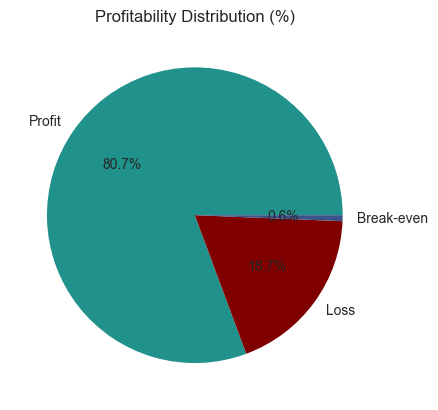

In [24]:
# visualization of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100

profit_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=[accent_color, danger_color, secondary_color]
)

plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

- ### KPIs

In [25]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df = df[df['Delay'] > 0]

metrics = {}

metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (
    1 - float(metrics['Late Deliveries']) / metrics['Total Orders']
) * 100

metrics['Late Delivery %'] = (
    float(metrics['Late Deliveries']) / metrics['Total Orders']
) * 100

metrics['Total Profit'] = format_func(
    df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum()
)

metrics['Total Loss due to delays'] = format_func(
    df.loc[df['Delay'] > 0, 'Order Profit Per Order'].sum()
)

print("\n--- Business KPIs ---\n")

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


--- Business KPIs ---

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


- ### Profitability versus Delivery Time Analysis

In [26]:
df['Delay'].value_counts()

Delay
 1    53503
 0    36650
 2    27551
-2    20873
-1    20719
 3     6772
 4     6697
Name: count, dtype: int64

In [27]:
profit_metrics = (
    df.groupby(['Delay'])['Order Profit Per Order'].agg(mean_profit='mean',total_profit='sum',order_count='count').reset_index()
)

In [28]:
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


- avg profit remains almost similar irrespective of the delay

In [29]:
delay_distribution = (
    df['Delay'].value_counts(normalize=True).sort_index()*100
).reset_index()

In [30]:
delay_distribution

,Delay,proportion
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


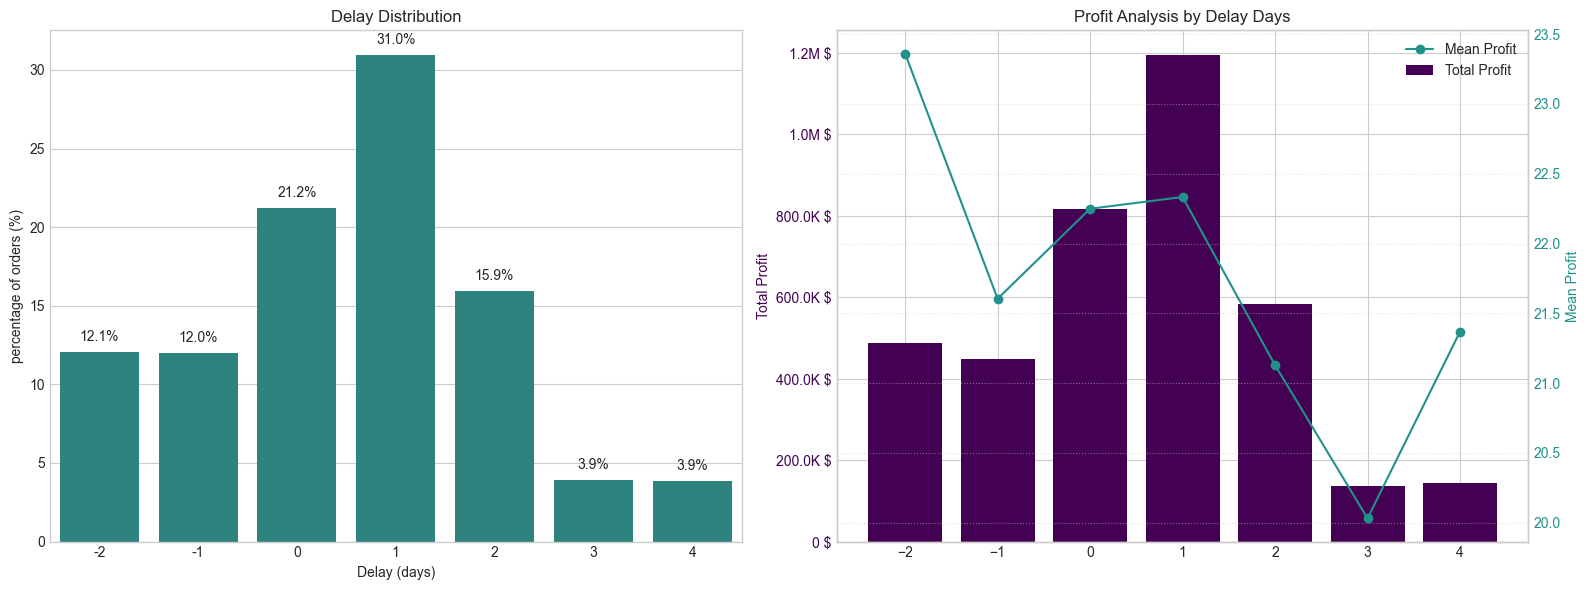

In [31]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# First subplot: Delay Distribution
sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

# percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel("Total Profit", color=primary_color)
ax2.bar(
    profit_metrics['Delay'],
    profit_metrics['total_profit'],
    color=primary_color,
    label='Total Profit'
)
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)
ax3.plot(
    profit_metrics['Delay'],
    profit_metrics['mean_profit'],
    marker='o',
    label='Mean Profit',
    color=accent_color
)
ax3.tick_params(axis='y', labelcolor=accent_color)

# Format total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax3.set_title("Profit Analysis by Delay Days")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax3.legend(
    lines + lines2,
    labels + labels2,
    loc='upper right'
)

ax3.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

- ## Bottleneck Detection

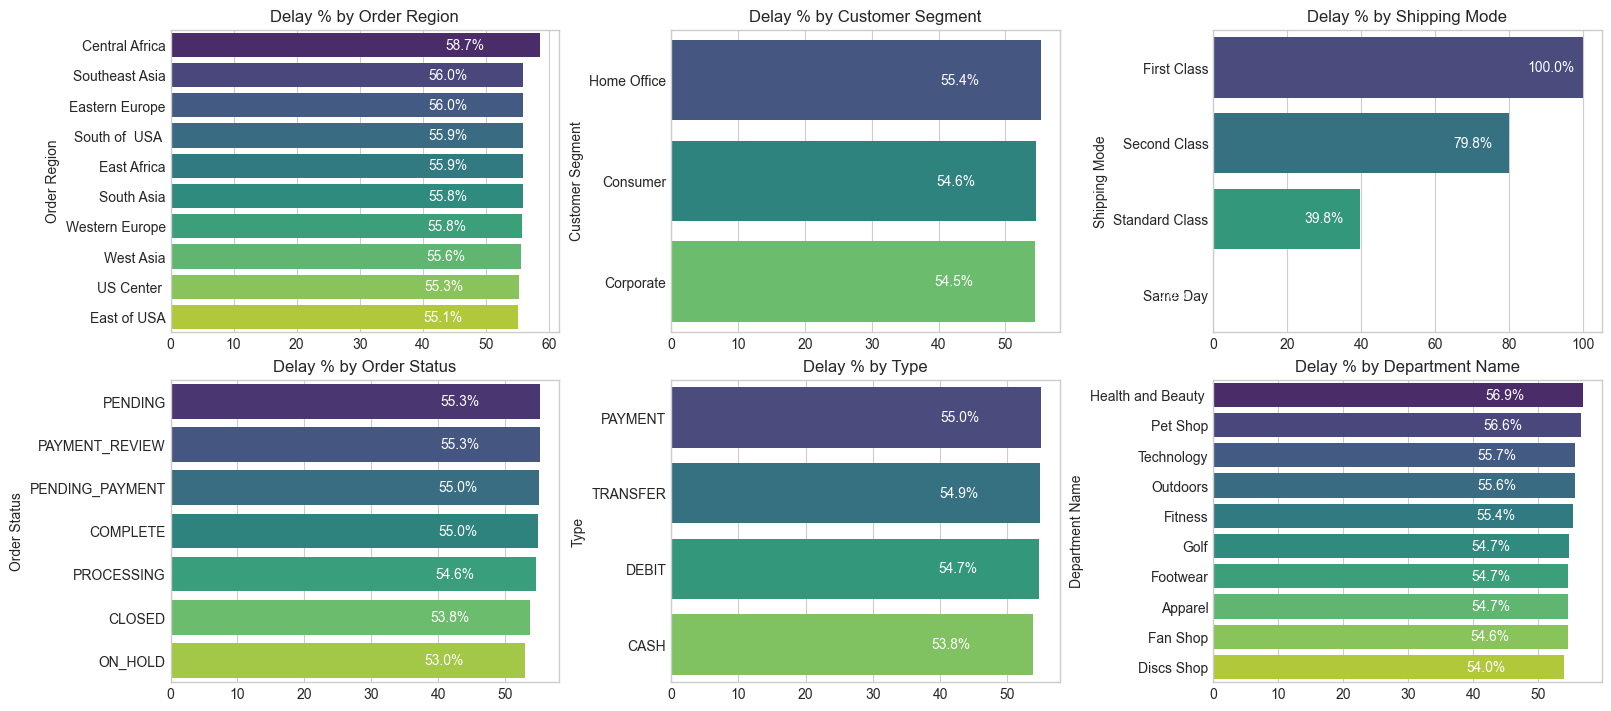

In [33]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = (
        cat_df['late_orders'] / cat_df['total_orders'] * 100
    )

    cat_df = cat_df.sort_values(
        'delay_pct',
        ascending=False
    ).head(10)

    return cat_df


categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(16, 7),
    constrained_layout=True
)

axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)

    for i, row in cat_df.reset_index().iterrows():
        ax.text(
            row['delay_pct'] - 15,
            i,
            f"{row['delay_pct']:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

plt.show()

### RCA (Root Cause Analysis)

In [34]:
df['Order Region'].value_counts()

Order Region
Central America    27174
Western Europe     25867
South America      14184
Oceania             9733
Northern Europe     9408
Southeast Asia      9136
Southern Europe     9030
Caribbean           7951
West of USA         7595
South Asia          7455
Eastern Asia        6973
East of USA         6617
West Asia           5746
US Center           5653
South of  USA       3855
Eastern Europe      3785
West Africa         3571
North Africa        3086
East Africa         1781
Central Africa      1616
Southern Africa     1100
Canada               907
Central Asia         542
Name: count, dtype: int64

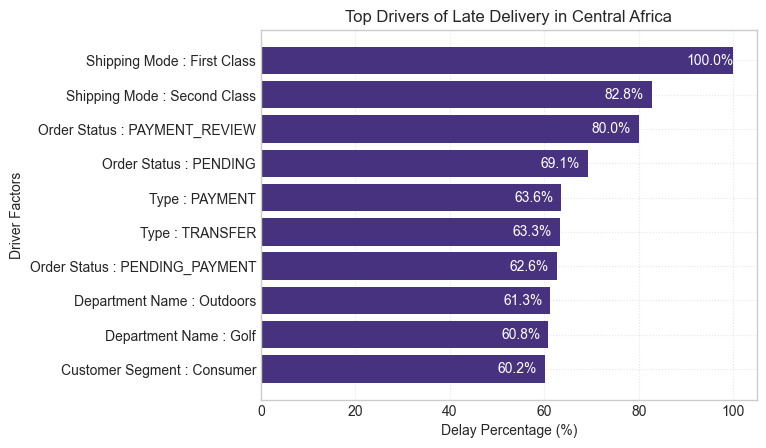

In [39]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = [
        'Shipping Mode',
        'Customer Segment',
        'Department Name',
        'Type',
        'Order Status'
    ]

    all_factors = []

    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = (
            temp['late_orders'] / temp['total_orders'] * 100
        )

        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )

    # Combine all drivers
    final_df = pd.concat(all_factors)

    # Top 10 drivers
    top_factors = final_df.sort_values(
        'delay_pct',
        ascending=False
    ).head(10)

    plt.figure()

    bars = plt.barh(
        top_factors['Factor_Level'],
        top_factors['delay_pct']
    )

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - 10,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

    plt.show()

top_drivers_for_region('Central Africa')

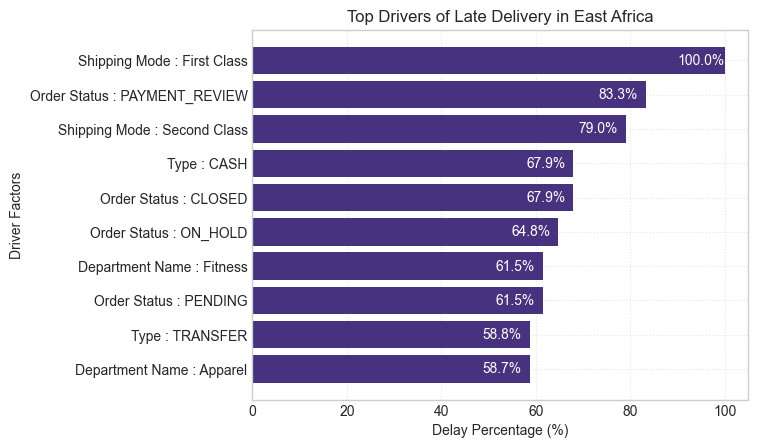

In [40]:
# Top drivers of late delivery by region

def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = [
        'Shipping Mode',
        'Customer Segment',
        'Department Name',
        'Type',
        'Order Status'
    ]

    all_factors = []

    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = (
            temp['late_orders'] / temp['total_orders'] * 100
        )

        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )

    # Combine all drivers
    final_df = pd.concat(all_factors)

    # Top 10 drivers
    top_factors = final_df.sort_values(
        'delay_pct',
        ascending=False
    ).head(10)

    plt.figure()

    bars = plt.barh(
        top_factors['Factor_Level'],
        top_factors['delay_pct']
    )

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - 10,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

    plt.show()

top_drivers_for_region('East Africa')

In [41]:
df.sample(2)

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,...,Product Price,shipping date (DateOrders),Shipping Mode,Order Processing Time,Delay,Is_Delayed,order_month,order_day,order_hour,Profitability Flag
123707,TRANSFER,6,4,27.969999,Late delivery,1,Books,Puerto Rico,Corporate,Book Shop,...,31.080000,2017-10-08 14:53:00,Standard Class,6,2,True,10,Monday,14,Profit
584,DEBIT,4,2,122.839996,Late delivery,1,Men's Footwear,Puerto Rico,Consumer,Apparel,...,129.990005,2016-10-13 22:44:00,Second Class,4,2,True,10,Sunday,22,Profit


In [39]:
# Top drivers of late delivery by Department Name

def top_drivers_for_department(department):
    df_department = df[df['Department Name'] == department].copy()

    drivers = [
        'Shipping Mode',
        'Customer Segment',
        'Order Region',
        'Type',
        'Order Status'
    ]

    all_factors = []

    for factor in drivers:
        temp = (
            df_department.groupby(factor)
            .agg(
                total_orders=('Delay', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delay', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = (
            temp['late_orders'] / temp['total_orders'] * 100
        )

        temp['Driver'] = factor
        temp['Factor_Level'] = factor + " : " + temp[factor].astype(str)

        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )

    # Combine all drivers
    final_df = pd.concat(all_factors)

    # Top 10 drivers
    top_factors = final_df.sort_values(
        'delay_pct',
        ascending=False
    ).head(10)

    plt.figure()

    bars = plt.barh(
        top_factors['Factor_Level'],
        top_factors['delay_pct']
    )

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - 10,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

    plt.show()

In [41]:
df['Department Name'].value_counts()

Department Name
Fan Shop              64033
Apparel               46884
Golf                  31768
Footwear              13891
Outdoors               9267
Fitness                2374
Discs Shop             1943
Technology             1396
Pet Shop                472
Book Shop               391
Health and Beauty       346
Name: count, dtype: int64

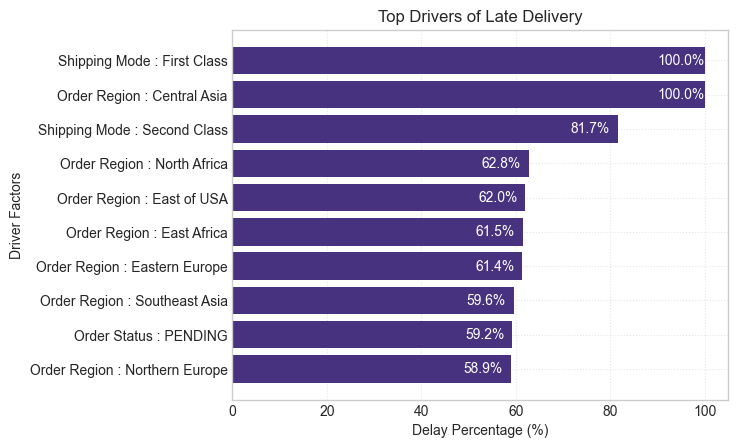

In [43]:
top_drivers_for_department('Fitness')

In [48]:
df_department = df[df['Department Name'] == 'Health and Beauty ']

print(df_department.shape)

(346, 27)


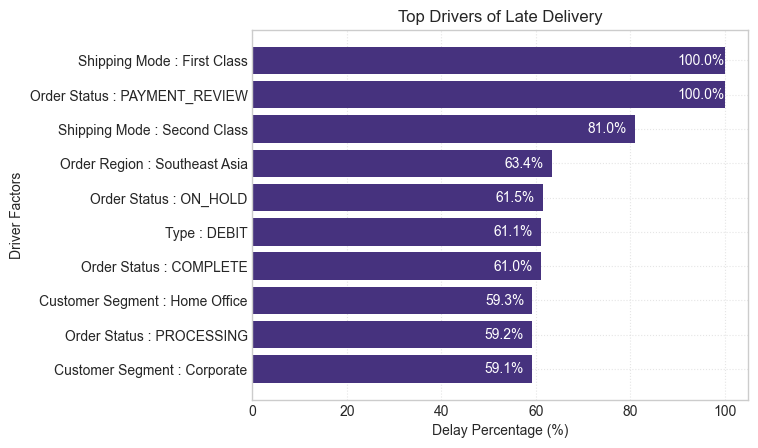

In [49]:
top_drivers_for_department('Health and Beauty ')

- First class shipping turns out to be a very big factor (driver) for delay in delivery

### Time based analysis

In [52]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour', 'Profitability Flag'],
      dtype='object')

- Year doesn't affect in supply chain, month, day of week and the time of day are bigger factors

In [53]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_month['delay_pct'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_day['delay_pct'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
      .mean()
      .reset_index()
)

delay_by_hour['delay_pct'] = delay_by_hour['Is_Delayed'] * 100

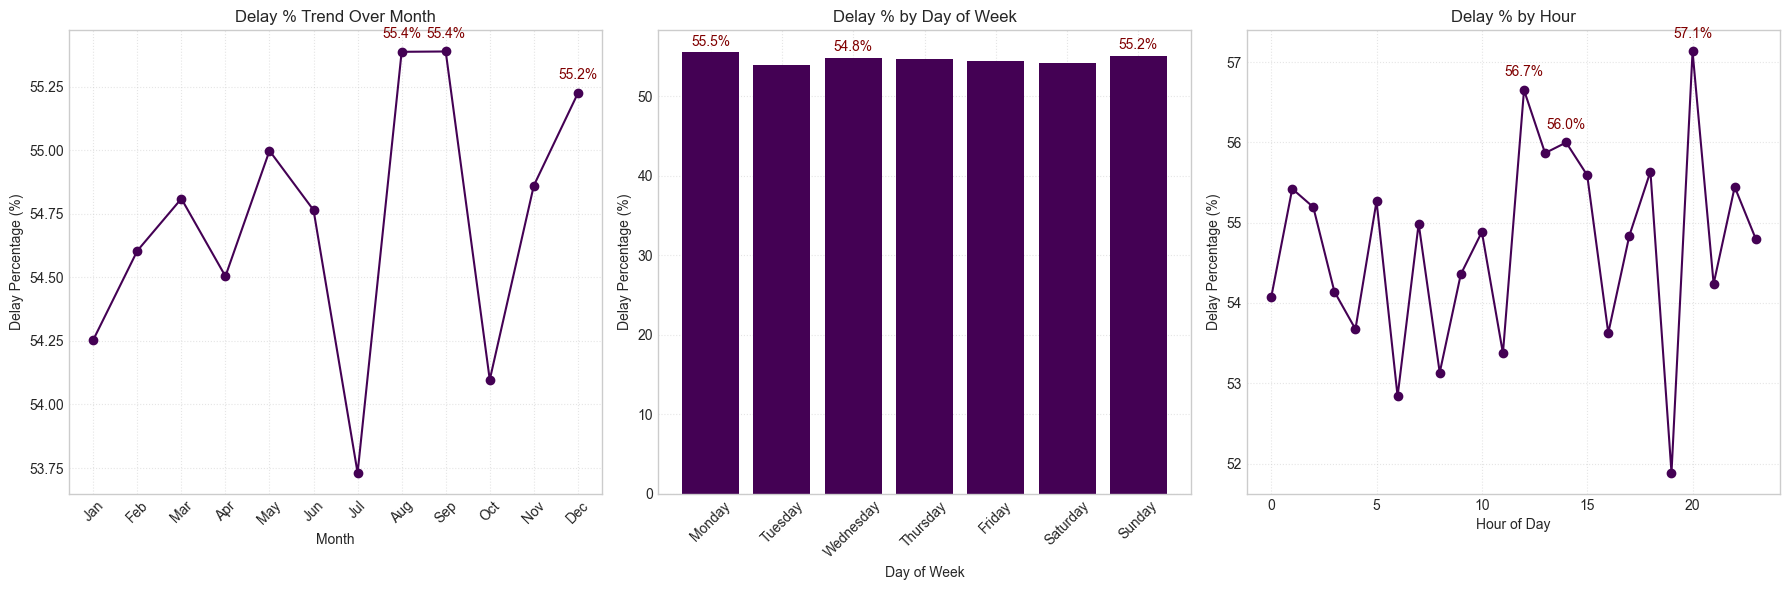

In [54]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(
    delay_by_month['order_month'],
    delay_by_month['delay_pct'],
    marker='o',
    color=primary_color
)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(
    ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
     'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
    rotation=45
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'delay_pct')

for _, row in top3_month.iterrows():
    ax1.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_month'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color=danger_color
    )

# Subplot 2: Delay % by Day of Week
day_order = [
    'Monday', 'Tuesday', 'Wednesday',
    'Thursday', 'Friday', 'Saturday', 'Sunday'
]

delay_by_day['order_day'] = pd.Categorical(
    delay_by_day['order_day'],
    categories=day_order,
    ordered=True
)

delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(
    delay_by_day['order_day'],
    delay_by_day['delay_pct'],
    color=primary_color
)

ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'delay_pct')

for _, row in top3_day.iterrows():
    height = row['delay_pct']
    ax2.text(
        row['order_day'],
        height + 0.5,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=10,
        color=danger_color
    )

# Subplot 3: Delay % by Hour
ax3.plot(
    delay_by_hour['order_hour'],
    delay_by_hour['delay_pct'],
    marker='o',
    color=primary_color
)

ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'delay_pct')

for _, row in top3_hour.iterrows():
    ax3.annotate(
        f"{row['delay_pct']:.1f}%",
        (row['order_hour'], row['delay_pct']),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=10,
        color=danger_color
    )

plt.tight_layout()
plt.show()

- Months of August, spetember and December see highest delay.
- Monday, Wednesday and Sunday sees highest delay in delivery.
- Ordering around 8pm resulted in high delivery delay 

## Predictive Model (classification output label: Delay or Not Delay)

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from collections import Counter
from imblearn.over_sampling import SMOTE

In [45]:
!pip install imblearn

Defaulting to user installation because normal site-packages is not writeable
  Using cached imblearn-0.0-py2.py3-none-any.whl.metadata (355 bytes)
Using cached imblearn-0.0-py2.py3-none-any.whl (1.9 kB)

   ---------------------------------------- 0/3 [sklearn-compat]
   ---------------------------------------- 0/3 [sklearn-compat]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-learn]
   ------------- -------------------------- 1/3 [imbalanced-le


[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [57]:
X = df[[
    'Type',
    'Days for shipment (scheduled)',
    'Category Name',
    'Customer Segment',
    'Department Name',
    'Order Region',
    'Shipping Mode',
    'order_month',
    'order_hour'
]]

y = df['Late_delivery_risk']

In [58]:
X

,Type,Days for shipment (scheduled),Category Name,Customer Segment,Department Name,Order Region,Shipping Mode,order_month,order_hour
0,DEBIT,4,Sporting Goods,Consumer,Fitness,Southeast Asia,Standard Class,1,22
1,TRANSFER,4,Sporting Goods,Consumer,Fitness,South Asia,Standard Class,1,12
2,CASH,4,Sporting Goods,Consumer,Fitness,South Asia,Standard Class,1,12
3,DEBIT,4,Sporting Goods,Home Office,Fitness,Oceania,Standard Class,1,11
4,PAYMENT,4,Sporting Goods,Corporate,Fitness,Oceania,Standard Class,1,11
...,...,...,...,...,...,...,...,...,...
180514,CASH,4,Fishing,Home Office,Fan Shop,Eastern Asia,Standard Class,1,3
180515,DEBIT,2,Fishing,Corporate,Fan Shop,Eastern Asia,Second Class,1,1
180516,TRANSFER,4,Fishing,Corporate,Fan Shop,Oceania,Standard Class,1,21
180517,PAYMENT,4,Fishing,Consumer,Fan Shop,Oceania,Standard Class,1,20


In [59]:
y

0         0
1         1
2         0
3         0
4         0
         ..
180514    0
180515    1
180516    1
180517    0
180518    0
Name: Late_delivery_risk, Length: 172765, dtype: int64

In [60]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)

# Frequency encoding (low-dimensional and robust for high-cardinality)
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# Keep numeric columns + new encoded features, drop original string categories
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq+target encoding:', X_encoded.shape)

# Use encoded features for modeling
X = X_encoded

# Train/test split after encoding
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode']
Shape after freq+target encoding: (172765, 9)


In [61]:
X_train

,Days for shipment (scheduled),order_month,order_hour,Type_freq,Category Name_freq,Customer Segment_freq,Department Name_freq,Order Region_freq,Shipping Mode_freq
92252,4,5,12,0.241513,0.000382,0.304043,0.080404,0.157289,0.597071
22501,4,3,21,0.401094,0.060863,0.517582,0.183880,0.056337,0.597071
121845,4,2,7,0.243851,0.123075,0.517582,0.271374,0.157289,0.597071
130407,4,3,14,0.401094,0.006581,0.517582,0.183880,0.040361,0.597071
131722,2,2,4,0.401094,0.106908,0.178375,0.370636,0.052881,0.195676
...,...,...,...,...,...,...,...,...,...
37566,2,7,16,0.241513,0.069158,0.517582,0.080404,0.054455,0.195676
3514,2,12,10,0.401094,0.136104,0.517582,0.271374,0.043151,0.195676
79796,2,4,18,0.401094,0.086129,0.517582,0.370636,0.032721,0.195676
26359,1,10,9,0.401094,0.003253,0.304043,0.008080,0.149724,0.153463


In [62]:
y.value_counts()

Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

In [63]:
# Check class distribution before oversampling
print("Before SMOTE:", Counter(y_train))

# Apply SMOTE only on the training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Check class distribution after oversampling
print("After SMOTE:", Counter(y_train_bal))

Before SMOTE: Counter({1: 79182, 0: 59030})
After SMOTE: Counter({0: 79182, 1: 79182})


In [64]:
# Train Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_bal, y_train_bal)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.7390964605099413
Precision: 0.7860934182590233
Recall   : 0.7481687294771406

Classification Report:

              precision    recall  f1-score   support

           0       0.68      0.73      0.70     14758
           1       0.79      0.75      0.77     19795

    accuracy                           0.74     34553
   macro avg       0.73      0.74      0.74     34553
weighted avg       0.74      0.74      0.74     34553



In [73]:
rf.feature_importances_

array([0.15697337, 0.13040561, 0.24330486, 0.04310153, 0.08674224,
       0.04209714, 0.03373584, 0.12933894, 0.13430048])

In [74]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

                         Feature  Importance
2                     order_hour    0.243305
0  Days for shipment (scheduled)    0.156973
8             Shipping Mode_freq    0.134300
1                    order_month    0.130406
7              Order Region_freq    0.129339
4             Category Name_freq    0.086742
3                      Type_freq    0.043102
5          Customer Segment_freq    0.042097
6           Department Name_freq    0.033736


In [66]:
X_test.columns

Index(['Days for shipment (scheduled)', 'order_month', 'order_hour',
       'Type_freq', 'Category Name_freq', 'Customer Segment_freq',
       'Department Name_freq', 'Order Region_freq', 'Shipping Mode_freq'],
      dtype='object')

In [67]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34553 entries, 84990 to 56550
Data columns (total 9 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Days for shipment (scheduled)  34553 non-null  int64  
 1   order_month                    34553 non-null  int32  
 2   order_hour                     34553 non-null  int32  
 3   Type_freq                      34553 non-null  float64
 4   Category Name_freq             34553 non-null  float64
 5   Customer Segment_freq          34553 non-null  float64
 6   Department Name_freq           34553 non-null  float64
 7   Order Region_freq              34553 non-null  float64
 8   Shipping Mode_freq             34553 non-null  float64
dtypes: float64(6), int32(2), int64(1)
memory usage: 2.4 MB


In [68]:
X_test.sample(2)

,Days for shipment (scheduled),order_month,order_hour,Type_freq,Category Name_freq,Customer Segment_freq,Department Name_freq,Order Region_freq,Shipping Mode_freq
67010,4,4,11,0.401094,0.069158,0.304043,0.080404,0.157289,0.597071
107847,4,4,18,0.241513,0.136104,0.517582,0.271374,0.082100,0.597071


In [72]:
rf.predict([[4,9,22,0.55,0.3,0.3,0.006,0.22,0.597]])

array([0])

## Final Insights

- First Class shiping is causing the major amount of delays in delivery, be it region wise or department wise.
- Central Africa is the region that is facing maximum delay in delivery.
- Health and Beauty deparment orders sees maximum delay in delivery.
- After doing time based analysis, I found out that August and September orders get delayed the most, I assume it maybe because of festive season in Asia, December sees similar delay amount, could be New year holidays' all over the world.
- 18% of the deliveries saw loss overall.
- The hour of the day order was placed, plays a major role in determining weather the delivery will be on time or not (got the insight from random forest model's feature importance analysis.)